### Importing important libraries

In [1]:
# Importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("C:\\Users\\91886\\Desktop\\My Computer\\Project_guvi\\Power house project\\household_power_consumption.txt", sep=';', 
                 parse_dates={'DateTime': ['Date', 'Time']}, 
                 infer_datetime_format=True, index_col='DateTime')

print(df.shape)
print(df.head())

C:\Users\91886\AppData\Local\Temp\ipykernel_20612\568640518.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("C:\\Users\\91886\\Desktop\\My Computer\\Project_guvi\\Power house project\\household_power_consumption.txt", sep=';',
C:\Users\91886\AppData\Local\Temp\ipykernel_20612\568640518.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv("C:\\Users\\91886\\Desktop\\My Computer\\Project_guvi\\Power house project\\household_power_consumption.txt", sep=';',
C:\Users\91886\AppData\Local\Temp\ipykernel_20612\568640518.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_me

(2075259, 7)
                    Global_active_power Global_reactive_power  Voltage  \
DateTime                                                                 
2006-12-16 17:24:00               4.216                 0.418  234.840   
2006-12-16 17:25:00               5.360                 0.436  233.630   
2006-12-16 17:26:00               5.374                 0.498  233.290   
2006-12-16 17:27:00               5.388                 0.502  233.740   
2006-12-16 17:28:00               3.666                 0.528  235.680   

                    Global_intensity Sub_metering_1 Sub_metering_2  \
DateTime                                                             
2006-12-16 17:24:00           18.400          0.000          1.000   
2006-12-16 17:25:00           23.000          0.000          1.000   
2006-12-16 17:26:00           23.000          0.000          2.000   
2006-12-16 17:27:00           23.000          0.000          1.000   
2006-12-16 17:28:00           15.800          0.

C:\Users\91886\AppData\Local\Temp\ipykernel_20612\568640518.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv("C:\\Users\\91886\\Desktop\\My Computer\\Project_guvi\\Power house project\\household_power_consumption.txt", sep=';',


In [3]:
print(df.info())
print(df.describe())

# Show first few rows
print(df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    object 
 1   Global_reactive_power  object 
 2   Voltage                object 
 3   Global_intensity       object 
 4   Sub_metering_1         object 
 5   Sub_metering_2         object 
 6   Sub_metering_3         float64
dtypes: float64(1), object(6)
memory usage: 126.7+ MB
None
       Sub_metering_3
count    2.049280e+06
mean     6.458447e+00
std      8.437154e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.700000e+01
max      3.100000e+01
                    Global_active_power Global_reactive_power  Voltage  \
DateTime                                                                 
2006-12-16 17:24:00               4.216                 0.418  234.840   
2006-12-16 17:25:00               5.360             

In [4]:
df.replace({'?': pd.NA}, inplace=True)

In [5]:
for col in ['Global_active_power', 'Global_reactive_power', 'Voltage',
'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
    
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
print(df.isnull().sum())

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [7]:
df.isnull()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,False,False,False,False,False,False,False
2006-12-16 17:25:00,False,False,False,False,False,False,False
2006-12-16 17:26:00,False,False,False,False,False,False,False
2006-12-16 17:27:00,False,False,False,False,False,False,False
2006-12-16 17:28:00,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
2010-11-26 20:58:00,False,False,False,False,False,False,False
2010-11-26 20:59:00,False,False,False,False,False,False,False
2010-11-26 21:00:00,False,False,False,False,False,False,False


In [8]:
df_fill = df.ffill()

In [9]:
df_clean = df.dropna()

In [10]:
df_clean_1 = df.interpolate()

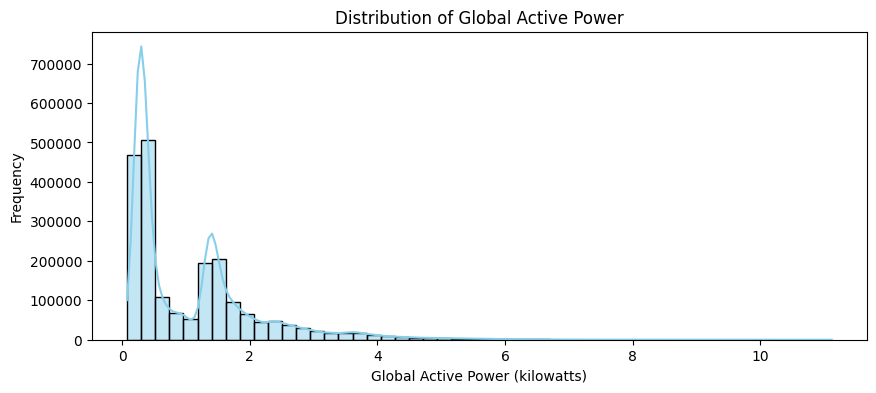

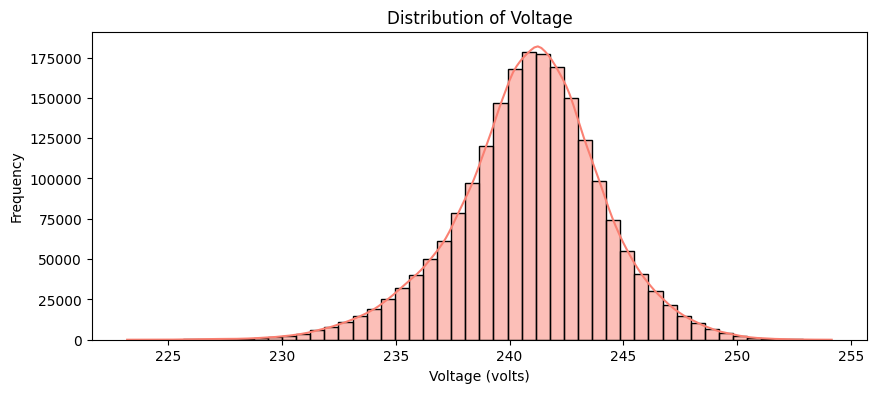

In [11]:
# Histograms and KDE plots
plt.figure(figsize=(10,4))
sns.histplot(df['Global_active_power'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Global Active Power')
plt.xlabel('Global Active Power (kilowatts)')
plt.ylabel('Frequency')
plt.show() 
plt.figure(figsize=(10,4))
sns.histplot(df['Voltage'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Voltage')
plt.xlabel('Voltage (volts)')
plt.ylabel('Frequency')
plt.show()

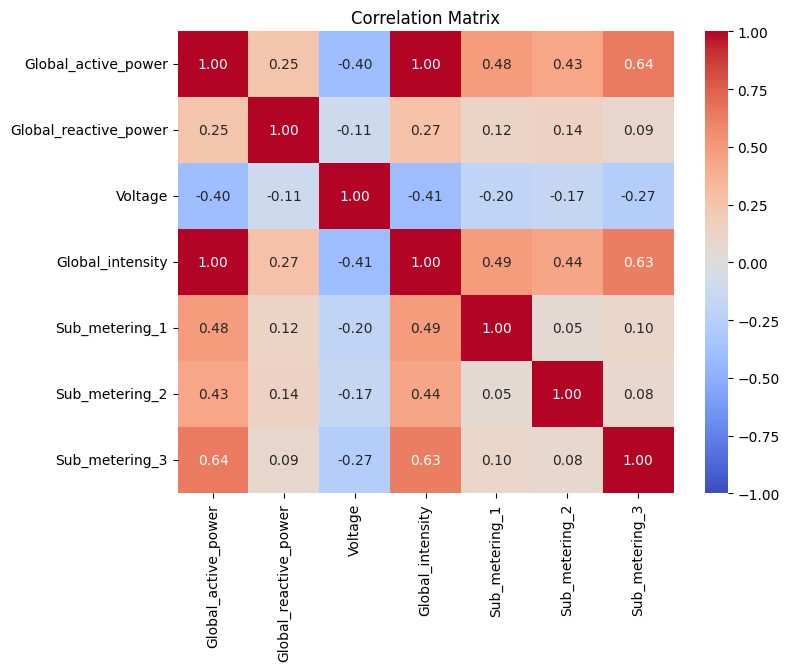

In [12]:
# Heat Map

# Compute correlation matrix
corr = df_clean.corr()

# Plot heatmap of correlations
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

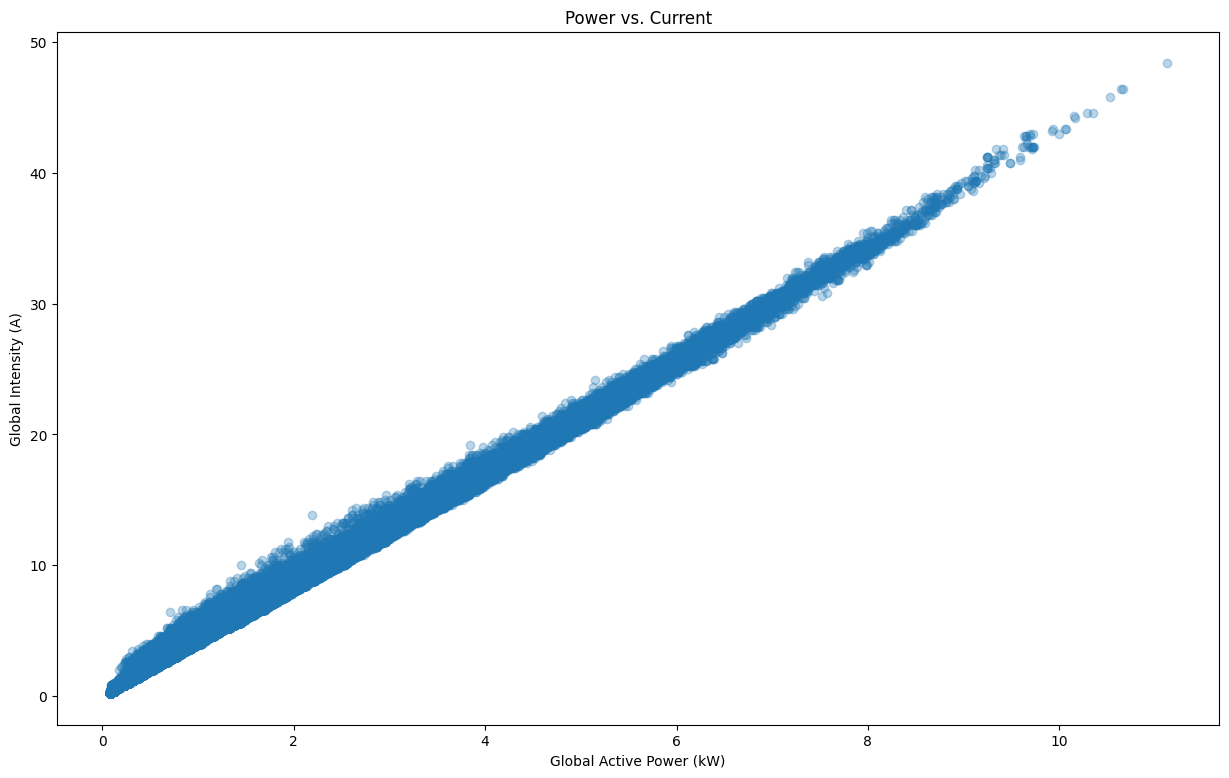

In [13]:
# Scatter plots
plt.figure(figsize=(15,9))
plt.scatter(df_clean['Global_active_power'], df_clean['Global_intensity'], alpha=0.3)
plt.title('Power vs. Current')
plt.xlabel('Global Active Power (kW)')
plt.ylabel('Global Intensity (A)')
plt.show()

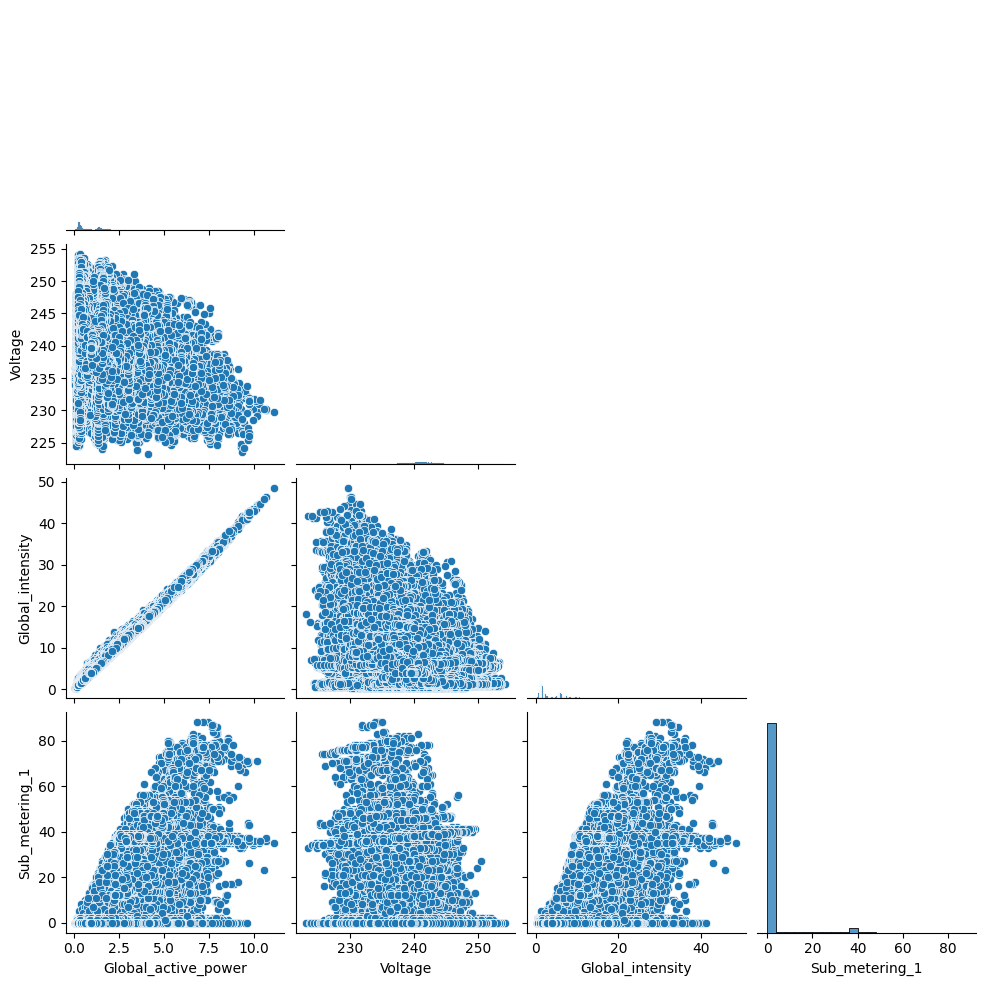

In [14]:
# Pairplot for selected numeric features

sns.pairplot(df_clean[['Global_active_power','Voltage','Global_intensity','Sub_metering_1']], 
           diag_kind='hist', corner=True)
plt.show()

###  Time Series Analysis

C:\Users\91886\AppData\Local\Temp\ipykernel_20612\2342028551.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_clean['Global_active_power'].resample('H').mean()


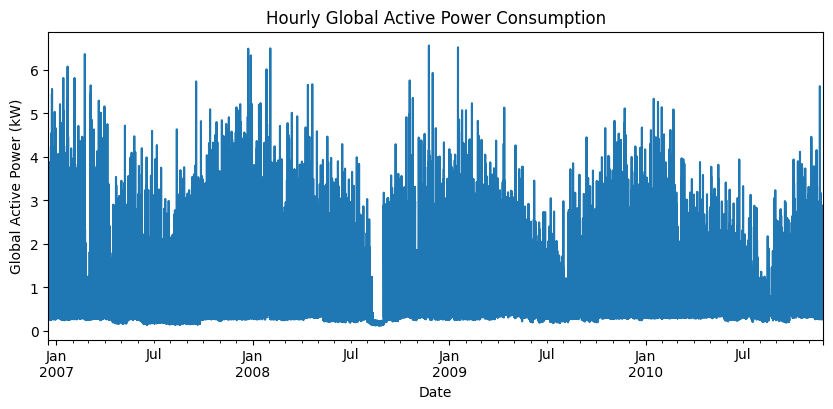

In [15]:
df_hourly = df_clean['Global_active_power'].resample('H').mean()
plt.figure(figsize=(10,4))
df_hourly.plot()
plt.title('Hourly Global Active Power Consumption')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.show()

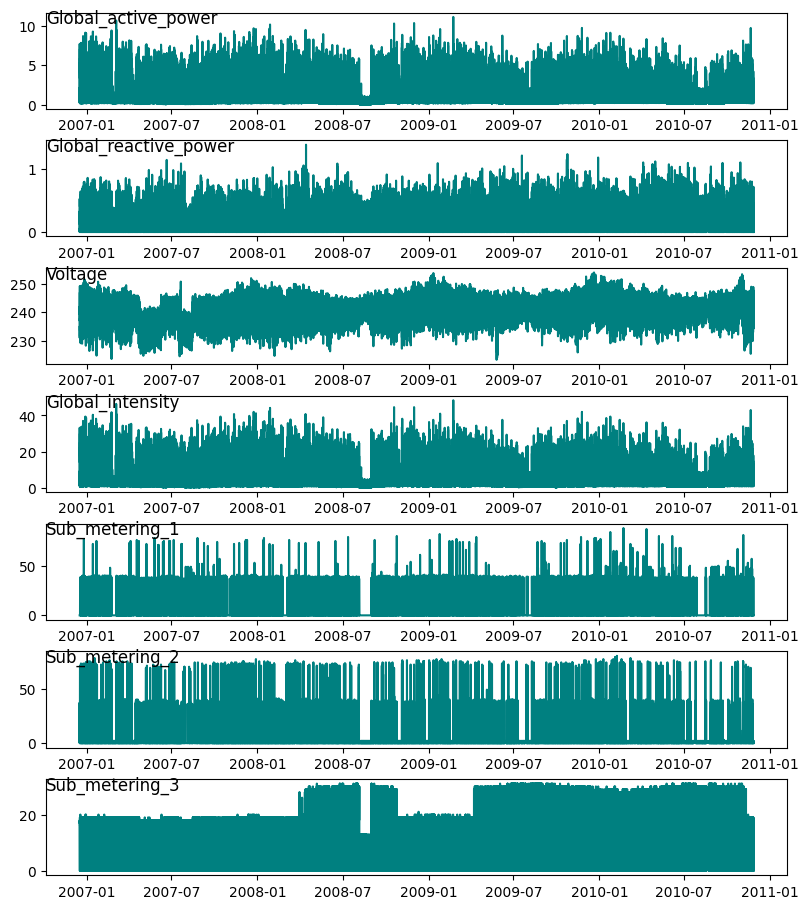

In [16]:
plt.figure(figsize=(8,9))
for i, col in enumerate(df_clean.columns, 1):
  plt.subplot(len(df_clean.columns), 1, i)
  plt.plot(df_clean.index, df_clean[col], color='teal')
  plt.title(col, loc='left', y=0.8)
  plt.tight_layout(pad=0.4)
plt.show()

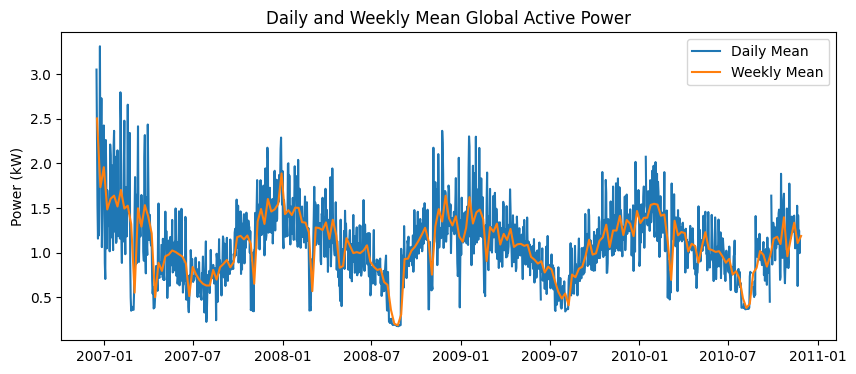

In [17]:
# Resampling for different granularities
daily_mean = df_clean['Global_active_power'].resample('D').mean()

#Plot daily and weekly rolling mean
plt.figure(figsize=(10,4))
plt.plot(df_clean['Global_active_power'].resample('D').mean(),
label='Daily Mean')
plt.plot(df_clean['Global_active_power'].resample('W').mean(),
label='Weekly Mean')
plt.legend()
plt.title('Daily and Weekly Mean Global Active Power')
plt.ylabel('Power (kW)')
plt.show()

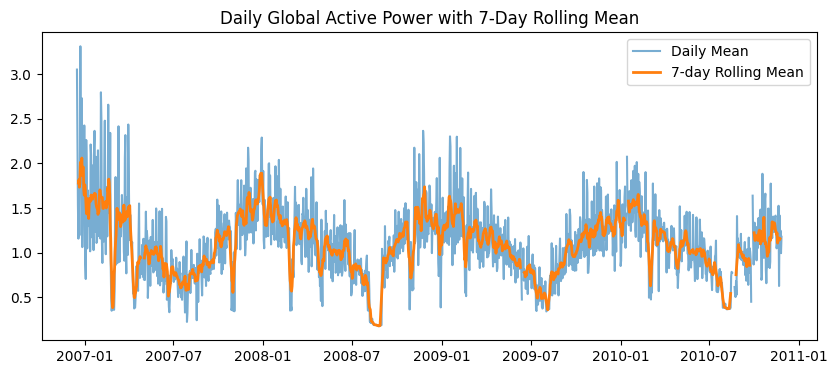

In [18]:
# 7-day rolling mean of daily data
daily = df_clean['Global_active_power'].resample('D').mean()
rolling7 = daily.rolling(window=7, center=True).mean()

plt.figure(figsize=(10,4))
plt.plot(daily, label='Daily Mean', alpha=0.6)
plt.plot(rolling7, label='7-day Rolling Mean', linewidth=2)
plt.legend()
plt.title('Daily Global Active Power with 7-Day Rolling Mean')
plt.show()

### Anomaly Detection

In [19]:
from scipy import stats
import numpy as np

In [20]:
# Use daily data for anomaly detection

daily_vals = daily.dropna()
z_scores = np.abs(stats.zscore(daily_vals))
anomalies = daily_vals[z_scores > 3] 
print("Anomalous days (Global_active_power):")
print(anomalies)

Anomalous days (Global_active_power):
DateTime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-23    3.314851
2006-12-26    2.732021
2006-12-31    2.426525
2007-01-21    2.366154
2007-02-03    2.798418
2007-02-04    2.497181
2007-02-11    2.480019
2007-02-18    2.659557
2007-03-11    2.417108
2007-03-31    2.437160
2008-11-23    2.366452
Name: Global_active_power, dtype: float64


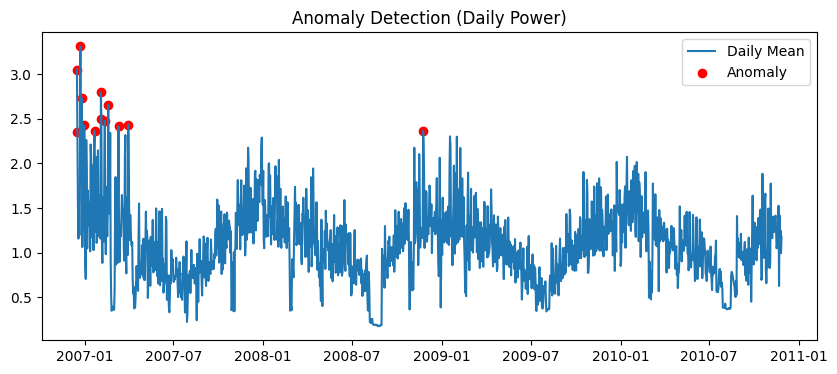

In [21]:
# This identifies days whose total/mean consumption is unusually high or low. We can then highlight these in a plot:

plt.figure(figsize=(10,4))
plt.plot(daily_vals, label='Daily Mean')
plt.scatter(anomalies.index, anomalies, color='red', label='Anomaly')
plt.legend()
plt.title('Anomaly Detection (Daily Power)')
plt.show()

### Feature Engineering

In [22]:
# Time-based features

df_feat = df_clean.copy()
df_feat['hour'] = df_feat.index.hour
df_feat['day_of_week'] = df_feat.index.dayofweek # 0=Monday
df_feat['month'] = df_feat.index.month
df_feat['is_weekend'] = df_feat['day_of_week'].isin([5,6]).astype(int)
print(df_feat[['hour','day_of_week','month','is_weekend']].head())

                     hour  day_of_week  month  is_weekend
DateTime                                                 
2006-12-16 17:24:00    17            5     12           1
2006-12-16 17:25:00    17            5     12           1
2006-12-16 17:26:00    17            5     12           1
2006-12-16 17:27:00    17            5     12           1
2006-12-16 17:28:00    17            5     12           1


In [23]:
# Assuming data is hourly or daily indexed
df_feat['lag_1h'] = df_feat['Global_active_power'].shift(1)  # 1 hour lag
df_feat['lag_24h'] = df_feat['Global_active_power'].shift(24) # 24 hours lag (if hourly data)

In [24]:
# Rolling mean smooths short-term fluctuations, capturing trends:
df_feat['rolling_mean_3'] = df_feat['Global_active_power'].rolling(window=3).mean()
df_feat['rolling_mean_24'] = df_feat['Global_active_power'].rolling(window=24).mean()

In [25]:
# Drop Missing Rows (from lags and rolling)
df_feat = df_feat.dropna()

### Regression Modeling

In [26]:
# Define features and target
X = df_feat.drop(columns=['Global_active_power'])
y = df_feat['Global_active_power']

# Train-test split (e.g. 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [27]:
# Standardize Features (Optional for Linear Models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Train Models
# Linear Regression

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred_lr = linreg.predict(X_test_scaled)

In [29]:
# Random Forest Regressor (for better non-linear performance)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### Evaluation Metrics

In [30]:

def evaluate_model(y_true, y_pred, name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name} Evaluation:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print("")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

Linear Regression Evaluation:
MAE: 0.0237
MSE: 0.0015
RMSE: 0.0386
R²: 0.9981

Random Forest Evaluation:
MAE: 0.0115
MSE: 0.0006
RMSE: 0.0252
R²: 0.9992

